# 01 - NER Exploratory Data Analysis

This notebook analyzes the standardized outputs in `data/processed` and prepares report-ready insights for:

1. Variables present in the dataset
2. Data issues and handling
3. Relationship of variables to project goal
4. Relationship among variables

Run top-to-bottom after dataset collection.

In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
# Colab helper: mount Google Drive if available
if Path('/content').exists():
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass

# Path resolution (prefer Google Drive, then Colab local, then local repo)
candidates = [
    Path('/content/drive/MyDrive/AAI590/data/processed'),
    Path('/content/drive/MyDrive/ner_capstone/data/processed'),
    Path('/content/ner_capstone/data/processed'),
    Path.cwd() / 'data' / 'processed',
]

processed_dir = next((p for p in candidates if p.exists()), None)
if processed_dir is None:
    raise FileNotFoundError(
        'Could not find data/processed. Place it in Drive (recommended) or local repo, then rerun.'
    )

print('Using processed dir:', processed_dir)

Mounted at /content/drive
Using processed dir: /content/drive/MyDrive/AAI590/data/processed


In [3]:
def load_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def split_entity_type(tag):
    if tag == 'O':
        return 'O'
    if '-' in tag:
        return tag.split('-', 1)[1]
    return tag


def extract_spans(tags):
    spans = []
    start = None
    cur_type = None
    for i, t in enumerate(tags):
        if t == 'O':
            if start is not None:
                spans.append((start, i - 1, cur_type))
                start, cur_type = None, None
            continue

        prefix, ent_type = (t.split('-', 1) + [''])[:2] if '-' in t else ('B', t)

        if prefix == 'B' or start is None or ent_type != cur_type:
            if start is not None:
                spans.append((start, i - 1, cur_type))
            start, cur_type = i, ent_type

    if start is not None:
        spans.append((start, len(tags) - 1, cur_type))

    return spans

In [4]:
dataset_names = ['conll2003', 'wnut17', 'scierc']
data = {}

for ds in dataset_names:
    ds_dir = processed_dir / ds
    split_files = sorted(ds_dir.glob(f'{ds}_*.jsonl'))
    data[ds] = {}
    for fp in split_files:
        split = fp.stem.replace(f'{ds}_', '')
        data[ds][split] = load_jsonl(fp)

print({ds: list(splits.keys()) for ds, splits in data.items()})

{'conll2003': ['test', 'train', 'validation'], 'wnut17': ['test', 'train', 'validation'], 'scierc': ['test', 'train', 'validation']}


In [5]:
# Dataset size overview
rows = []
for ds, splits in data.items():
    for split, samples in splits.items():
        num_sent = len(samples)
        num_tok = sum(len(x['tokens']) for x in samples)
        num_ent_tok = sum(sum(1 for t in x['tags'] if t != 'O') for x in samples)
        rows.append({
            'dataset': ds,
            'split': split,
            'sentences': num_sent,
            'tokens': num_tok,
            'entity_tokens': num_ent_tok,
            'entity_token_rate': num_ent_tok / num_tok if num_tok else 0.0,
        })

size_df = pd.DataFrame(rows).sort_values(['dataset', 'split'])
display(size_df)

,dataset,split,sentences,tokens,entity_tokens,entity_token_rate
0,conll2003,test,3453,46435,8112,0.174696
1,conll2003,train,14041,203621,34043,0.167188
2,conll2003,validation,3250,51362,8603,0.167497
6,scierc,test,551,13401,3934,0.293560
7,scierc,train,1861,45412,13000,0.286268
8,scierc,validation,275,6521,1945,0.298267
3,wnut17,test,1287,23394,1740,0.074378
4,wnut17,train,3394,62730,3160,0.050375
5,wnut17,validation,1009,15733,1250,0.079451


### Interpretation: Dataset Size Overview

- **Observation:** Dataset splits differ in sentence/token counts and entity-token rates.
- **Why it matters:** Uneven supervision and entity density influence transfer difficulty and few-shot variance.
- **Decision:** Use matched budgets (50/100/200), fixed seeds, and consistent evaluation across methods.

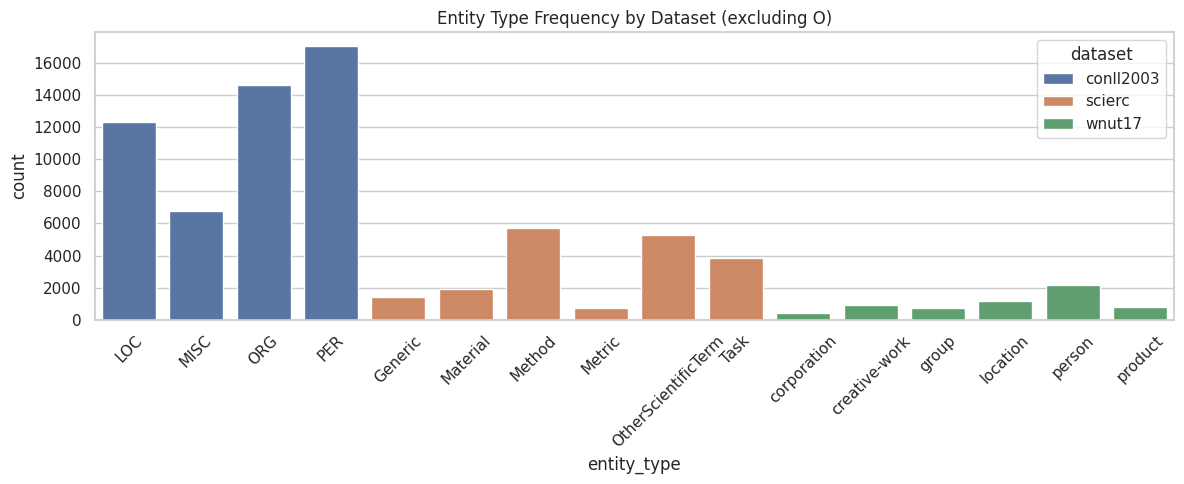

,dataset,tag,count
7,conll2003,O,250660
6,conll2003,I-PER,17050
5,conll2003,I-ORG,14584
3,conll2003,I-LOC,12299
4,conll2003,I-MISC,6729
1,conll2003,B-MISC,50
2,conll2003,B-ORG,29
0,conll2003,B-LOC,17
20,scierc,O,46455
16,scierc,I-Method,3627


In [6]:
# Tag and entity-type distributions
label_rows = []
entity_rows = []

for ds, splits in data.items():
    for split, samples in splits.items():
        tag_counter = Counter()
        ent_counter = Counter()
        for s in samples:
            tag_counter.update(s['tags'])
            ent_counter.update(split_entity_type(t) for t in s['tags'])

        for tag, c in tag_counter.items():
            label_rows.append({'dataset': ds, 'split': split, 'tag': tag, 'count': c})
        for ent, c in ent_counter.items():
            entity_rows.append({'dataset': ds, 'split': split, 'entity_type': ent, 'count': c})

label_df = pd.DataFrame(label_rows)
entity_df = pd.DataFrame(entity_rows)

plot_df = (
    entity_df[entity_df['entity_type'] != 'O']
    .groupby(['dataset', 'entity_type'], as_index=False)['count'].sum()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x='entity_type', y='count', hue='dataset')
plt.title('Entity Type Frequency by Dataset (excluding O)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(
    label_df.groupby(['dataset', 'tag'], as_index=False)['count'].sum()
    .sort_values(['dataset', 'count'], ascending=[True, False])
    .groupby('dataset').head(15)
)

### Interpretation: Tag and Entity-Type Distribution

- **Observation:** `O` tags dominate and entity-type frequencies are imbalanced across datasets.
- **Why it matters:** Aggregate metrics can hide weaknesses on rare or domain-specific entity types.
- **Decision:** Report entity-level metrics in addition to micro F1, and preserve balanced few-shot sampling where possible.

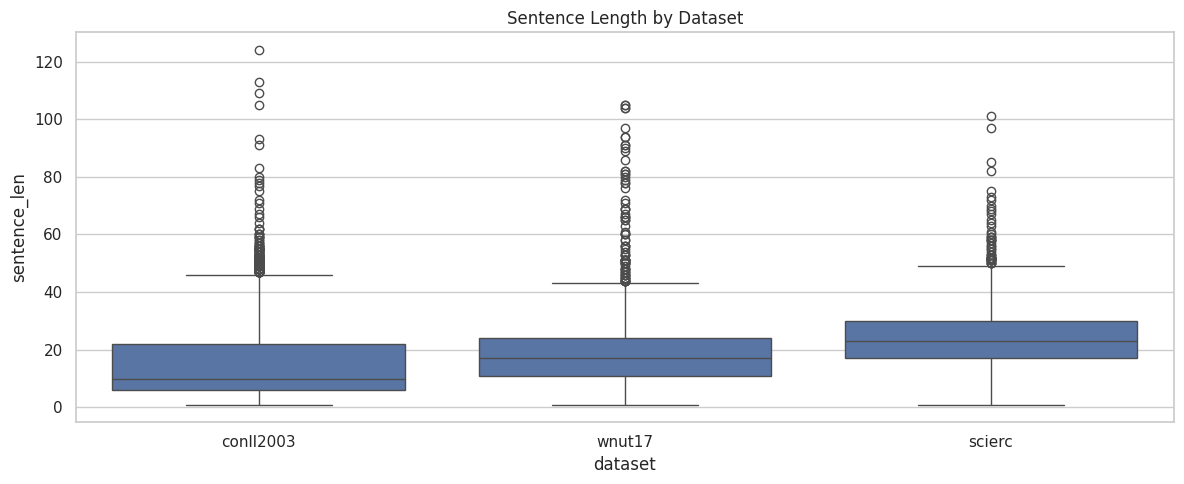

,count,mean,std,min,50%,90%,95%,max
dataset,,,,,,,,
conll2003,20744.0,14.530370,11.775436,1.0,10.0,33.0,38.0,124.0
scierc,2687.0,24.314849,10.025946,1.0,23.0,37.0,42.0,101.0
wnut17,5690.0,17.901054,10.091995,1.0,17.0,29.0,32.0,105.0


In [7]:
# Sentence length distributions
len_rows = []
for ds, splits in data.items():
    for split, samples in splits.items():
        for s in samples:
            len_rows.append({
                'dataset': ds,
                'split': split,
                'sentence_len': len(s['tokens'])
            })

len_df = pd.DataFrame(len_rows)

plt.figure(figsize=(12, 5))
sns.boxplot(data=len_df, x='dataset', y='sentence_len')
plt.title('Sentence Length by Dataset')
plt.tight_layout()
plt.show()

display(
    len_df.groupby('dataset')['sentence_len']
    .describe(percentiles=[0.5, 0.9, 0.95])
)

### Interpretation: Sentence Length Distribution

- **Observation:** Sentence-length profiles differ across domains and splits.
- **Why it matters:** Length differences can affect context availability, truncation behavior, and entity density patterns.
- **Decision:** Keep tokenization/truncation settings consistent across methods and report any length-related failure modes.

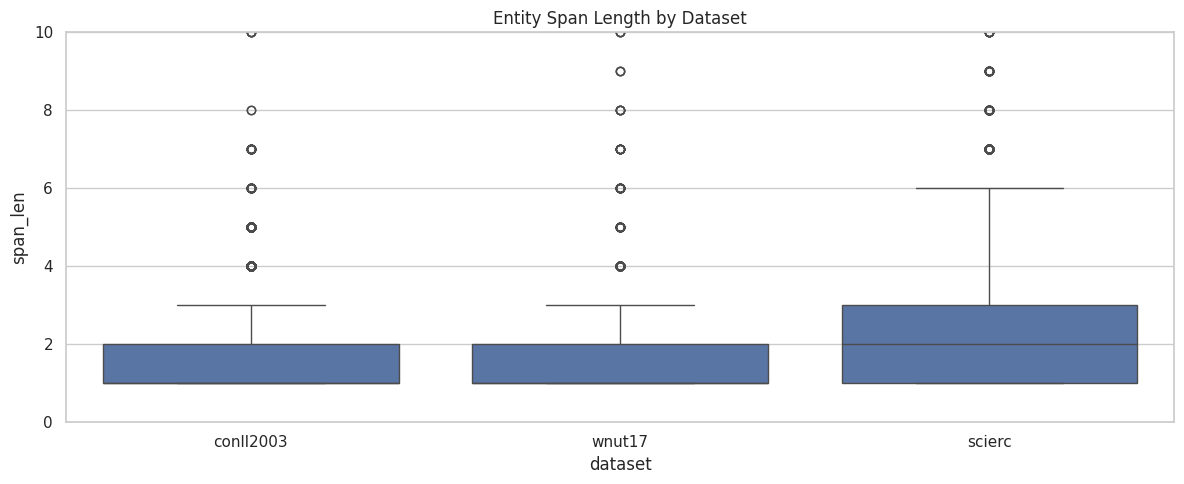

,count,mean,std,min,50%,90%,95%,max
dataset,,,,,,,,
conll2003,35089.0,1.446550,0.693144,1.0,1.0,2.0,3.0,10.0
scierc,8084.0,2.335354,1.496660,1.0,2.0,4.0,5.0,13.0
wnut17,3890.0,1.580977,1.126710,1.0,1.0,3.0,3.0,25.0


In [8]:
# Entity span lengths
span_rows = []
for ds, splits in data.items():
    for split, samples in splits.items():
        for s in samples:
            spans = extract_spans(s['tags'])
            for start, end, ent_type in spans:
                span_rows.append({
                    'dataset': ds,
                    'split': split,
                    'entity_type': ent_type,
                    'span_len': end - start + 1,
                })

span_df = pd.DataFrame(span_rows)

plt.figure(figsize=(12, 5))
sns.boxplot(data=span_df, x='dataset', y='span_len')
plt.ylim(0, max(10, int(span_df['span_len'].quantile(0.99)) + 1))
plt.title('Entity Span Length by Dataset')
plt.tight_layout()
plt.show()

display(span_df.groupby('dataset')['span_len'].describe(percentiles=[0.5, 0.9, 0.95]))

### Interpretation: Entity Span Lengths

- **Observation:** Span-length distributions vary by dataset and include longer multi-token entities in some domains.
- **Why it matters:** Longer spans increase boundary prediction difficulty and can depress strict span-level F1.
- **Decision:** Include boundary-focused error analysis and monitor per-entity performance for long-span-heavy classes.

,dataset,train_vocab_size,vocab_overlap_with_conll_train,rare_token_ratio_in_train
0,conll2003,21009,1.000000,0.049406
1,wnut17,12840,0.293536,0.145624
2,scierc,5485,0.433911,0.055250


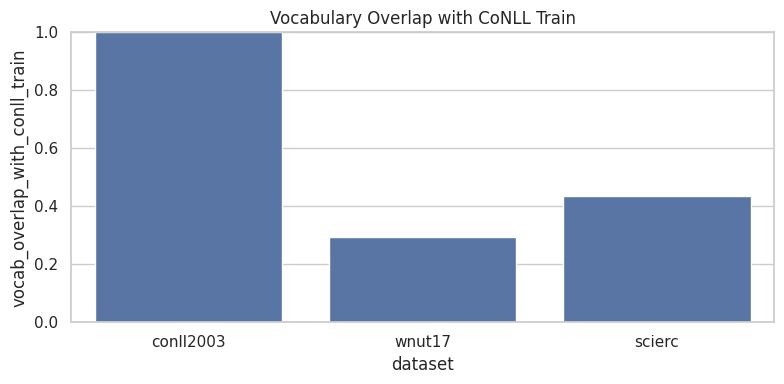

In [9]:
# Domain-shift signals: vocabulary overlap + rare-token ratio
train_vocab = {}
for ds in dataset_names:
    train_samples = data[ds].get('train', [])
    vocab = Counter(tok.lower() for s in train_samples for tok in s['tokens'])
    train_vocab[ds] = vocab

base_vocab = set(train_vocab['conll2003'].keys()) if 'conll2003' in train_vocab else set()

shift_rows = []
for ds in dataset_names:
    vocab = train_vocab.get(ds, Counter())
    cur_vocab = set(vocab.keys())
    overlap = len(base_vocab & cur_vocab) / len(cur_vocab) if cur_vocab else 0.0

    total = sum(vocab.values())
    rare = sum(c for _, c in vocab.items() if c == 1)
    rare_ratio = rare / total if total else 0.0

    shift_rows.append({
        'dataset': ds,
        'train_vocab_size': len(cur_vocab),
        'vocab_overlap_with_conll_train': overlap,
        'rare_token_ratio_in_train': rare_ratio,
    })

shift_df = pd.DataFrame(shift_rows)
display(shift_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=shift_df, x='dataset', y='vocab_overlap_with_conll_train')
plt.title('Vocabulary Overlap with CoNLL Train')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Interpretation: Vocabulary Shift and Rare Tokens

- **Observation:** Target-domain vocabularies only partially overlap with CoNLL and contain non-trivial rare-token mass.
- **Why it matters:** This signals domain shift and helps explain expected degradation of a CoNLL-trained baseline.
- **Decision:** Prioritize DAP and include cost-performance analysis to test whether adaptation gains justify added compute.

In [10]:
# Save compact EDA summary for downstream reporting
eda_summary = {
    'size_overview': size_df.to_dict(orient='records'),
    'vocab_shift': shift_df.to_dict(orient='records'),
}

out_path = processed_dir / 'eda_summary.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=True)

print('Saved:', out_path)

Saved: /content/drive/MyDrive/AAI590/data/processed/eda_summary.json


## Additional EDA: Label Harmonization, Few-Shot Coverage, Rare Classes

These cells add three high-impact checks before modeling:

1. Label harmonization diagnostics across datasets
2. Few-shot coverage sanity for budgets 50/100/200
3. Rare-class alert table for low-frequency entity types

In [11]:
# 1) Label harmonization diagnostics

def normalize_entity_type(tag):
    if tag == 'O':
        return 'O'
    if '-' in tag:
        return tag.split('-', 1)[1]
    return tag

entity_type_rows = []
entity_type_sets = {}

for ds in dataset_names:
    train_samples = data[ds].get('train', [])
    etypes = Counter()
    for s in train_samples:
        etypes.update(normalize_entity_type(t) for t in s['tags'] if t != 'O')

    entity_type_sets[ds] = set(etypes.keys())
    for et, c in etypes.items():
        entity_type_rows.append({'dataset': ds, 'entity_type': et, 'train_token_count': c})

entity_type_df = pd.DataFrame(entity_type_rows).sort_values(['dataset', 'train_token_count'], ascending=[True, False])
display(entity_type_df)

intersection_types = sorted(set.intersection(*entity_type_sets.values())) if entity_type_sets else []
union_types = sorted(set.union(*entity_type_sets.values())) if entity_type_sets else []

harmonization_summary = pd.DataFrame([
    {'metric': 'intersection_entity_types_across_all_datasets', 'value': ', '.join(intersection_types) if intersection_types else '(none)'},
    {'metric': 'union_entity_type_count', 'value': len(union_types)},
    {'metric': 'conll2003_entity_types', 'value': ', '.join(sorted(entity_type_sets.get('conll2003', set())))},
    {'metric': 'wnut17_entity_types', 'value': ', '.join(sorted(entity_type_sets.get('wnut17', set())))},
    {'metric': 'scierc_entity_types', 'value': ', '.join(sorted(entity_type_sets.get('scierc', set())))},
])

display(harmonization_summary)

print('Recommendation: keep dataset-specific full-label evaluations, and document any harmonized subset explicitly.')

,dataset,entity_type,train_token_count
2,conll2003,PER,11128
0,conll2003,ORG,10025
3,conll2003,LOC,8297
1,conll2003,MISC,4593
13,scierc,Method,3905
11,scierc,OtherScientificTerm,3567
14,scierc,Task,2658
10,scierc,Material,1356
12,scierc,Generic,1029
15,scierc,Metric,485


,metric,value
0,intersection_entity_types_across_all_datasets,(none)
1,union_entity_type_count,16
2,conll2003_entity_types,"LOC, MISC, ORG, PER"
3,wnut17_entity_types,"corporation, creative-work, group, location, p..."
4,scierc_entity_types,"Generic, Material, Method, Metric, OtherScient..."


Recommendation: keep dataset-specific full-label evaluations, and document any harmonized subset explicitly.


In [12]:
# 2) Few-shot coverage sanity (budget/seed)
import random

def sent_has_entity(sample):
    return any(t != 'O' for t in sample['tags'])


def sample_fewshot(samples, budget, seed):
    rng = random.Random(seed)
    positives = [s for s in samples if sent_has_entity(s)]
    negatives = [s for s in samples if not sent_has_entity(s)]

    rng.shuffle(positives)
    rng.shuffle(negatives)

    n_pos = min(len(positives), max(1, int(round(0.8 * budget))))
    n_neg = min(len(negatives), budget - n_pos)
    chosen = positives[:n_pos] + negatives[:n_neg]

    if len(chosen) < budget:
        used = set(id(x) for x in chosen)
        leftovers = [s for s in samples if id(s) not in used]
        rng.shuffle(leftovers)
        chosen.extend(leftovers[: budget - len(chosen)])

    rng.shuffle(chosen)
    return chosen[:budget]


BUDGETS = [50, 100, 200]
SEEDS = [13, 42, 101]
TARGET_DATASETS = ['wnut17', 'scierc']

fewshot_rows = []
for ds in TARGET_DATASETS:
    train_samples = data[ds].get('train', [])
    for b in BUDGETS:
        for s in SEEDS:
            subset = sample_fewshot(train_samples, budget=b, seed=s)
            subset_tags = [t for row in subset for t in row['tags'] if t != 'O']
            subset_types = set(normalize_entity_type(t) for t in subset_tags)
            fewshot_rows.append({
                'dataset': ds,
                'budget': b,
                'seed': s,
                'num_sentences': len(subset),
                'num_entity_sentences': sum(sent_has_entity(x) for x in subset),
                'num_entity_tokens': len(subset_tags),
                'num_entity_types_present': len(subset_types),
            })

fewshot_cov_df = pd.DataFrame(fewshot_rows).sort_values(['dataset', 'budget', 'seed'])
display(fewshot_cov_df)

display(
    fewshot_cov_df.groupby(['dataset', 'budget'], as_index=False)
    .agg(
        avg_entity_sentences=('num_entity_sentences', 'mean'),
        avg_entity_tokens=('num_entity_tokens', 'mean'),
        avg_entity_types=('num_entity_types_present', 'mean')
    )
)

,dataset,budget,seed,num_sentences,num_entity_sentences,num_entity_tokens,num_entity_types_present
9,scierc,50,13,50,40,280,6
10,scierc,50,42,50,40,292,6
11,scierc,50,101,50,40,334,6
12,scierc,100,13,100,80,593,6
13,scierc,100,42,100,80,615,6
14,scierc,100,101,100,80,656,6
15,scierc,200,13,200,160,1228,6
16,scierc,200,42,200,160,1246,6
17,scierc,200,101,200,160,1313,6
0,wnut17,50,13,50,40,105,6


,dataset,budget,avg_entity_sentences,avg_entity_tokens,avg_entity_types
0,scierc,50,40.0,302.000000,6.0
1,scierc,100,80.0,621.333333,6.0
2,scierc,200,160.0,1262.333333,6.0
3,wnut17,50,40.0,100.666667,6.0
4,wnut17,100,80.0,202.333333,6.0
5,wnut17,200,160.0,414.333333,6.0


### Interpretation: Label Harmonization Diagnostics

- **Observation:** Entity inventories differ across datasets, with only partial overlap in entity types.
- **Why it matters:** Cross-domain comparisons can be confounded if label definitions are not harmonized or clearly documented.
- **Decision:** Use dataset-specific full-label evaluation by default and document any harmonized subset explicitly in the report.

In [13]:
# 3) Rare-class alerts (train split)
RARE_THRESHOLD = 50

rare_rows = []
for ds in dataset_names:
    train_samples = data[ds].get('train', [])
    c = Counter()
    for s in train_samples:
        c.update(normalize_entity_type(t) for t in s['tags'] if t != 'O')

    for et, count in c.items():
        rare_rows.append({
            'dataset': ds,
            'entity_type': et,
            'train_token_count': count,
            'is_rare': count < RARE_THRESHOLD,
        })

rare_df = pd.DataFrame(rare_rows).sort_values(['dataset', 'train_token_count'])
rare_alert_df = rare_df[rare_df['is_rare']].copy()

print(f'Rare threshold: < {RARE_THRESHOLD} train tokens')
if rare_alert_df.empty:
    print('No rare classes under current threshold.')
else:
    display(rare_alert_df)

display(
    rare_df.groupby('dataset', as_index=False)
    .agg(
        num_entity_types=('entity_type', 'nunique'),
        num_rare_entity_types=('is_rare', 'sum')
    )
)

print('Use this table to flag unstable per-entity F1 expectations in low-budget runs.')

Rare threshold: < 50 train tokens
No rare classes under current threshold.


,dataset,num_entity_types,num_rare_entity_types
0,conll2003,4,0
1,scierc,6,0
2,wnut17,6,0


Use this table to flag unstable per-entity F1 expectations in low-budget runs.


### Interpretation: Few-Shot Coverage Sanity

- **Observation:** Entity coverage grows with budget, but 50-example subsets may not fully represent all entity types.
- **Why it matters:** Low coverage can create high variance and method comparisons can be sensitive to sample composition.
- **Decision:** Keep matched seeds/budgets across methods and report mean plus variability across seeds.

### Interpretation: Rare-Class Alerts

- **Observation:** Some entity types appear very infrequently in training data under the current rare-class threshold.
- **Why it matters:** These classes will likely have unstable and lower per-entity F1, especially at 50-label and 100-label budgets.
- **Decision:** Report per-entity results with variance across seeds, and explicitly flag rare classes when interpreting model performance.